# Team 9 ML Training and Testing


*   Create a test set and a training set using the original dataset
*   Follow the steps that we use in our hands-ons to prepare the data and pipeline for training at least 3 ML models. Use any strategy that you see fit. Use N-fold cross-validation to evaluate the performance of each model.
*   Graphs for initial data exploration
*   Description of test data and test strategy you use
* Select the best performance metrics to evaluate your models for testing and explain why you choose this model
* Test your best ML model using the test set. Include a confusion matrix to show the performance of your best class ML model.





# Create a test set and a training set using the original dataset

In [40]:
import pandas as pd
from sklearn.model_selection import StratifiedShuffleSplit, StratifiedKFold, cross_val_score
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    recall_score,
    precision_score,
    roc_auc_score,
    f1_score,
    ConfusionMatrixDisplay,
)
import matplotlib.pyplot as plt


In [41]:
diabetes_df = pd.read_csv('diabetes_dataset.csv')


kept_stages = ["Type 2", "Pre-Diabetes", "No Diabetes", "Type 1"]
diabetes_df = diabetes_df[diabetes_df["diabetes_stage"].isin(kept_stages)].copy()
diabetes_df = diabetes_df.reset_index(drop=True)

print("Filtered dataset shape:", diabetes_df.shape)
print(diabetes_df["diabetes_stage"].value_counts())

diabetes_df.head()

Filtered dataset shape: (99722, 31)
diabetes_stage
Type 2          59774
Pre-Diabetes    31845
No Diabetes      7981
Type 1            122
Name: count, dtype: int64


,age,gender,ethnicity,education_level,income_level,employment_status,smoking_status,alcohol_consumption_per_week,physical_activity_minutes_per_week,diet_score,...,hdl_cholesterol,ldl_cholesterol,triglycerides,glucose_fasting,glucose_postprandial,insulin_level,hba1c,diabetes_risk_score,diabetes_stage,diagnosed_diabetes
0,58,Male,Asian,Highschool,Lower-Middle,Employed,Never,0,215,5.7,...,41,160,145,136,236,6.36,8.18,29.6,Type 2,1
1,48,Female,White,Highschool,Middle,Employed,Former,1,143,6.7,...,55,50,30,93,150,2.00,5.63,23.0,No Diabetes,0
2,60,Male,Hispanic,Highschool,Middle,Unemployed,Never,1,57,6.4,...,66,99,36,118,195,5.07,7.51,44.7,Type 2,1
3,74,Female,Black,Highschool,Low,Retired,Never,0,49,3.4,...,50,79,140,139,253,5.28,9.03,38.2,Type 2,1
4,46,Male,White,Graduate,Middle,Retired,Never,1,109,7.2,...,52,125,160,137,184,12.74,7.20,23.5,Type 2,1


In [42]:
split = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
for train_index, test_index in split.split(diabetes_df, diabetes_df["diabetes_stage"]):
    strat_train_set = diabetes_df.iloc[train_index]
    strat_test_set = diabetes_df.iloc[test_index]

# Prepare the Data and Pipeline for Training at least 3 ML Models


*   Use N-fold cross-validation to evaluate the performance of each model




## Data Cleaning and Pipeline

In [43]:
diabetes_df.isnull().sum().sum()

0

In [44]:
diabetes_df.describe()

,age,alcohol_consumption_per_week,physical_activity_minutes_per_week,diet_score,sleep_hours_per_day,screen_time_hours_per_day,family_history_diabetes,hypertension_history,cardiovascular_history,bmi,...,cholesterol_total,hdl_cholesterol,ldl_cholesterol,triglycerides,glucose_fasting,glucose_postprandial,insulin_level,hba1c,diabetes_risk_score,diagnosed_diabetes
count,99722.000000,99722.000000,99722.000000,99722.000000,99722.000000,99722.000000,99722.000000,99722.000000,99722.000000,99722.000000,...,99722.000000,99722.000000,99722.000000,99722.000000,99722.000000,99722.000000,99722.000000,99722.000000,99722.000000,99722.000000
mean,50.162542,2.003570,118.902910,5.994658,6.997943,5.996391,0.219460,0.251048,0.079361,25.614355,...,186.005565,54.042167,103.026283,121.461443,111.124225,160.037083,9.062023,6.520929,30.236289,0.600068
std,15.600843,1.417892,84.413045,1.780789,1.094583,2.468359,0.413883,0.433618,0.270302,3.586153,...,32.008075,10.270531,33.390455,43.367153,13.596249,30.940390,4.954197,0.814045,9.060263,0.489886
min,18.000000,0.000000,0.000000,0.000000,3.000000,0.500000,0.000000,0.000000,0.000000,15.000000,...,100.000000,20.000000,50.000000,30.000000,60.000000,70.000000,2.000000,4.000000,2.700000,0.000000
25%,39.000000,1.000000,57.000000,4.800000,6.300000,4.300000,0.000000,0.000000,0.000000,23.200000,...,164.000000,47.000000,78.000000,91.000000,102.000000,139.000000,5.090000,5.970000,23.800000,0.000000
50%,50.000000,2.000000,100.000000,6.000000,7.000000,6.000000,0.000000,0.000000,0.000000,25.600000,...,186.000000,54.000000,102.000000,121.000000,111.000000,160.000000,8.790000,6.520000,29.000000,1.000000
75%,61.000000,3.000000,160.000000,7.200000,7.700000,7.700000,0.000000,1.000000,0.000000,28.000000,...,208.000000,61.000000,126.000000,151.000000,120.000000,181.000000,12.450000,7.070000,35.600000,1.000000
max,90.000000,10.000000,833.000000,10.000000,10.000000,16.800000,1.000000,1.000000,1.000000,39.200000,...,318.000000,98.000000,263.000000,344.000000,172.000000,287.000000,32.220000,9.800000,67.200000,1.000000


In [45]:
# Drop target column from features
target_col = "diabetes_stage"

X_train = strat_train_set.drop(columns=[target_col])
y_train = strat_train_set[target_col]
X_test = strat_test_set.drop(columns=[target_col])
y_test = strat_test_set[target_col]

# Split columns into numeric and categorical groups
num_attribs = X_train.select_dtypes(include="number").columns.tolist()
cat_attribs = X_train.select_dtypes(include=["object", "category"]).columns.tolist()

# Pipeline for numeric columns
num_pipeline = Pipeline(
    [
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ]
)

# Pipeline for categorical columns
cat_pipeline = Pipeline(
    [
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
    ]
)

# Combine pipelines
full_pipeline = ColumnTransformer(
    [
        ("num", num_pipeline, num_attribs),
        ("cat", cat_pipeline, cat_attribs),
    ]
)

print("Target class distribution in training set:")
print(y_train.value_counts(normalize=True).round(4))
print("Numeric columns:", len(num_attribs))
print("Categorical columns:", len(cat_attribs))


Target class distribution in training set:
diabetes_stage
Type 2          0.5994
Pre-Diabetes    0.3193
No Diabetes     0.0800
Type 1          0.0012
Name: proportion, dtype: float64
Numeric columns: 24
Categorical columns: 6


## First Model

In [46]:
log_reg_pipeline = Pipeline([
    ("preprocess", full_pipeline),
    (
        "model",
        LogisticRegression(
            max_iter=2000,
            random_state=42,
            class_weight="balanced",
            solver="lbfgs",
        ),
    ),
])

log_reg_pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['age',
                                                   'alcohol_consumption_per_week',
                                                   'physical_activity_minutes_per_week',
                                                   'diet_score',
                                                   'sleep_hours_per_day',
                                                   'screen_time_hours_per_day',
                                                   'family_history_diabetes',
                                                   'hypertension_history',
                                                   'ca...
                                                   'diagnosed_diabetes']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  ['gender', 'ethnicity',
                                                   'education_level',
                                                   'income_level',
                                                   'employment_status',
                                                   'smoking_status'])])),
                ('model',
                 LogisticRegression(class_weight='balanced', max_iter=2000,
                                    random_state=42))])

In [47]:

knn_scores = cross_val_score(
    log_reg_pipeline,
    X_train,
    y_train,
    cv=5,
    scoring="f1_macro",
)

def display_scores(scores):
    print("Scores:", scores)
    print("Mean:", scores.mean())
    print("Standard deviation:", scores.std())

display_scores(knn_scores)

Scores: [0.65894542 0.66132807 0.66248161 0.65907334 0.66247236]
Mean: 0.6608601593487008
Standard deviation: 0.0015688345915733618


## Second Model

In [48]:
knn_pipeline = Pipeline([
    ("preprocess", full_pipeline),
    ("model", KNeighborsClassifier(n_neighbors=15)),
])

knn_scores = cross_val_score(
    knn_pipeline,
    X_train,
    y_train,
    cv=5,
    scoring="f1_macro",
)

display_scores(knn_scores)

Scores: [0.62955753 0.62455738 0.63904641 0.63183498 0.64009772]
Mean: 0.6330188023083014
Standard deviation: 0.005855264209523285


## Third Model

In [49]:
rf_pipeline = Pipeline([
    ("preprocess", full_pipeline),
    (
        "model",
        RandomForestClassifier(
            n_estimators=300,
            random_state=42,
            class_weight="balanced_subsample",
            n_jobs=-1,
        ),
    ),
])

rf_scores = cross_val_score(
    rf_pipeline,
    X_train,
    y_train,
    cv=5,
    scoring="f1_macro",
)

display_scores(rf_scores)

Scores: [0.74933132 0.7494388  0.74950213 0.74952503 0.749564  ]
Mean: 0.7494722573745184
Standard deviation: 8.133465507069883e-05


# Select the best performance metrics to evaluate your models for testing and explain why you choose this model

# Test your best ML model using the test set. Include a confusion matrix to show the performance of your best class ML model.

Model: Random Forest
Accuracy: 0.9987465530208072
Recall: 0.75
Precision: 0.748771535439533
F1: 0.7493851891909912
ROC AUC: 0.8849666672038055


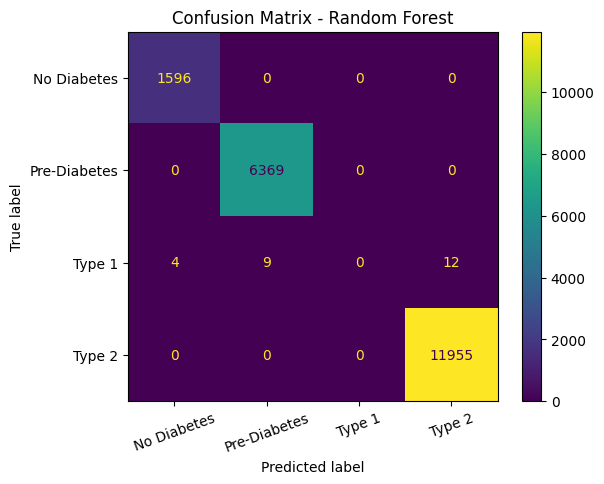

In [51]:
# Final testing with Random Forest on test set
rf_pipeline.fit(X_train, y_train)

y_pred = rf_pipeline.predict(X_test)
y_proba = rf_pipeline.predict_proba(X_test)

print("Model: Random Forest")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred, average="macro", zero_division=0))
print("Precision:", precision_score(y_test, y_pred, average="macro", zero_division=0))
print("F1:", f1_score(y_test, y_pred, average="macro", zero_division=0))
print("ROC AUC:", roc_auc_score(y_test, y_proba, multi_class="ovo"))


ConfusionMatrixDisplay.from_predictions(y_test, y_pred, xticks_rotation=20)
plt.title("Confusion Matrix - Random Forest")
plt.show()